# 10-K Due Diligence Assistant: RAG with Verifiable Citations

**Docker image**: `ml4t-gpu`

**Chapter 22: RAG for Financial Research**

This notebook builds a 10-K due-diligence RAG (Retrieval-Augmented Generation)
assistant on top of LlamaIndex. Key features:

1. **Sentence-window chunking** - `SentenceSplitter` over the canonical 10-K
   parquet text (LlamaParse-style structure-aware parsing is a production
   upgrade discussed in §22.3, not implemented here)
2. **Dense vector retrieval** - local BGE-small embeddings indexed in ChromaDB
3. **Constraint-Based Prompting** - enforcing grounded, citable answers
4. **Numeric Retrieve→Extract→Compute→Narrate** - code-side arithmetic on
   extracted figures so the LLM never does the math itself
5. **Harness Diagnostics** - lightweight retrieval/citation/abstention checks

## Learning Objectives
- Build a citation-constrained 10-K assistant with abstention checks.
- Run the retrieve-extract-compute-narrate pattern for numeric questions.
- Analyze RAG pipeline error sources and select/justify components.

**Book Reference**: Chapter 22, Section 22.8 (Applications)

## Prerequisites
- SP100 10-K filings (`data/equities/fundamentals/10k/sp100/`)
- OpenAI API key for LLM generation (optional - retrieval works without it)
- Embeddings use local HuggingFace model (no API key needed)

## 1. Setup and Imports

This setup fixes the document budget, retrieval depth, and optional
dependencies that determine whether the notebook runs a full or fallback RAG path.

In [1]:
"""10-K Due Diligence Assistant - RAG pipeline with verifiable citations for SEC filings."""

import os
import re
import warnings
from dataclasses import dataclass
from pathlib import Path

warnings.filterwarnings("ignore")

import chromadb
import plotly.graph_objects as go
import torch

# LlamaIndex core + ChromaDB + OpenAI LLM backend
from llama_index.core import (
    Document,
    PromptTemplate,
    Settings,
    SimpleDirectoryReader,
    StorageContext,
    VectorStoreIndex,
)
from llama_index.core.node_parser import SentenceSplitter
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.openai import OpenAI as OpenAILLM
from llama_index.vector_stores.chroma import ChromaVectorStore

# ML4T configuration
from data import DataNotFoundError, iter_sec_filings
from utils.paths import get_output_dir
from utils.style import COLORS, show_plotly_with_alt

VECTOR_STORE_DIR = get_output_dir(22, "10k_rag_assistant") / "vector_store"
VECTOR_STORE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
MAX_DOCS = 20
TOP_K = 5
RUN_LIVE_LLM = False
REQUIRE_GPU = True

In [3]:
if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("This embedding workload requires the ml4t-gpu service with CUDA.")

EMBEDDING_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMBEDDING_CACHE_DIR = os.environ.get("HF_HUB_CACHE")
BGE_REVISION = "5c38ec7c405ec4b44b94cc5a9bb96e735b38267a"
OPENAI_AVAILABLE = RUN_LIVE_LLM and bool(os.getenv("OPENAI_API_KEY"))
if RUN_LIVE_LLM and not OPENAI_AVAILABLE:
    raise RuntimeError("RUN_LIVE_LLM=True requires OPENAI_API_KEY.")

print("LlamaIndex + ChromaDB available")
print(f"Embedding device: {EMBEDDING_DEVICE}")
print(f"Generation mode: {'live OpenAI' if OPENAI_AVAILABLE else 'retrieval only'}")
print()
print(f"Max documents: {MAX_DOCS}")
print(f"Similarity top_k: {TOP_K}")

# Data source - prefer the canonical SP100 10-K parquet corpus.
# A flat directory of PDF/TXT/MD files remains a fallback for ad hoc
# experiments without the staged dataset.
HAS_CANONICAL_CORPUS = True
try:
    _peek = next(iter_sec_filings(form_type="10-K", universe="sp100"), None)
    if _peek is None:
        HAS_CANONICAL_CORPUS = False
except DataNotFoundError:
    HAS_CANONICAL_CORPUS = False

SEC_FILINGS_DIR = get_output_dir(22, "sec_filing_pipeline") / "sec_filings_10k"
SEC_FILINGS_DIR.mkdir(parents=True, exist_ok=True)

LlamaIndex + ChromaDB available
Embedding device: cuda
Generation mode: retrieval only

Max documents: 20
Similarity top_k: 5


**Interpretation**: The parameters shrink the corpus and retrieval breadth for
quick tests, but the notebook still exercises the same RAG pipeline that the
production chapter discussion describes.

## 2. Document Ingestion

The implemented path uses sentence-window chunking over canonical filing text.
A production parser can additionally preserve sections and tables, but those
properties are not measured by this notebook.

### Load filings from disk

Prefer the staged SP100 parquet corpus produced upstream. Flat PDF, TXT, and
Markdown files remain supported for ad hoc experiments, but the notebook no
longer fabricates a sample filing when the real corpus is missing.

In [4]:
def load_canonical_documents(max_docs: int = 10):
    """Load a stable first-N slice of canonical SP100 10-K filings."""
    documents = []
    records = [
        record
        for record in iter_sec_filings(form_type="10-K", universe="sp100")
        if record.get("text")
    ]
    records.sort(
        key=lambda record: (
            str(record["symbol"]),
            str(record["filing_date"]),
            str(record["accession_no"]),
        )
    )
    for record in records[:max_docs]:
        accession_no = record["accession_no"]
        metadata = {
            "symbol": record["symbol"],
            "cik": record.get("cik"),
            "year": record.get("year"),
            "filing_date": str(record["filing_date"]),
            "company_name": record.get("company_name"),
            "accession_no": accession_no,
        }
        documents.append(Document(text=record["text"], doc_id=accession_no, metadata=metadata))
    return documents

### Load and route filing formats

When the canonical SP100 corpus is available, stream 10-K records from it.
Otherwise fall back to flat PDF/TXT/MD files from the notebook's scratch dir.

In [5]:
def load_documents(filings_dir: Path, max_docs: int = 10):
    """Load 10-K filings: canonical parquet corpus first, flat-file fallback otherwise."""
    if HAS_CANONICAL_CORPUS:
        print(f"Loading up to {max_docs} 10-K filings from canonical SP100 corpus")
        documents = load_canonical_documents(max_docs)
        print(f"Loaded {len(documents)} parquet-backed documents")
        return documents

    pdf_files = sorted(filings_dir.rglob("*.pdf"))
    txt_files = sorted(filings_dir.rglob("*.txt"))
    md_files = sorted(filings_dir.rglob("*.md"))
    all_files = (pdf_files + txt_files + md_files)[:max_docs]

    if not all_files:
        raise FileNotFoundError(
            "No staged 10-K filings found. Run 01_sec_filing_pipeline.py or point "
            f"SEC_FILINGS_DIR at a directory of PDF/TXT/MD filings under {filings_dir}."
        )

    print(f"Loading {len(all_files)} documents from {filings_dir}")
    reader = SimpleDirectoryReader(
        input_files=[str(f) for f in all_files],
        filename_as_id=True,
    )
    documents = reader.load_data()
    print(f"Loaded {len(documents)} document chunks")
    return documents

**Interpretation**: `load_documents` is the first grounding checkpoint. The
notebook either streams the canonical SP100 parquet corpus or reads flat
PDF/TXT/MD files from `SEC_FILINGS_DIR`. If neither path is populated, the
loader raises `FileNotFoundError` rather than silently substituting synthetic
text - there is no synthetic fallback in the current code path.


In [6]:
# Load documents
documents = load_documents(SEC_FILINGS_DIR, MAX_DOCS)

if documents:
    print("\nSample document preview (first 500 chars):")
    print("-" * 50)
    print(documents[0].text[:500])
    print("-" * 50)

Loading up to 20 10-K filings from canonical SP100 corpus
Loaded 20 parquet-backed documents

Sample document preview (first 500 chars):
--------------------------------------------------
ctures, and by emulating the Company’s products and infringing on its intellectual property.

The Company’s ability to compete successfully depends heavily on ensuring the continuing and timely introduction of innovative new products, services and technologies to the marketplace. The Company believes it is unique in that it designs and develops nearly the entire solution for its products, including the hardware, operating system, numerous software applications and related services. Principal com
--------------------------------------------------


**Interpretation**: The loaded filings preserve the key challenge of
filing retrieval: long, heterogeneous documents need to retain enough structure
for later citations and multi-hop questions to remain grounded.

## 3. Chunking and Embedding

We split documents into sentence windows and create embeddings using a local
general-purpose model. Specialized financial candidates require a judged
comparison before making a quality claim.

Here we use the local `BAAI/bge-small-en-v1.5` model so the notebook runs
without any API key; OpenAI `text-embedding-3-small` or voyage-finance-2 are
drop-in alternatives when those API keys are available.

### Configure LlamaIndex settings

Sets the LLM, embedding model, and chunk strategy. ChromaDB persists the
index, so a restart does not re-embed the corpus.

### Build the Retrieval Index

This function configures chunking, embeddings, and optional ChromaDB
persistence, then materializes the index used by the query engine.

In [7]:
def create_index(documents, persist_dir: Path = None):
    """Create vector index with SentenceSplitter chunking and optional ChromaDB persistence."""
    if not documents:
        print("Cannot create index - no documents")
        return None

    # Local embeddings (no API key required)
    embed_model = HuggingFaceEmbedding(
        model_name="BAAI/bge-small-en-v1.5",
        device=EMBEDDING_DEVICE,
        cache_folder=EMBEDDING_CACHE_DIR,
        revision=BGE_REVISION,
    )
    parameter_device = next(embed_model._model.parameters()).device
    if REQUIRE_GPU and parameter_device.type != "cuda":
        raise RuntimeError(f"Embedding parameters are on {parameter_device}, not CUDA.")
    print(f"Embedding parameters: {parameter_device}")
    Settings.embed_model = embed_model

    # LLM: OpenAI if available, otherwise retrieval-only
    if OPENAI_AVAILABLE:
        Settings.llm = OpenAILLM(model="gpt-4o-mini", temperature=0.1)
    else:
        Settings.llm = None

    Settings.node_parser = SentenceSplitter(
        chunk_size=512, chunk_overlap=50, paragraph_separator="\n\n"
    )
    return _build_vector_index(documents, persist_dir)

In [8]:
def _build_vector_index(documents, persist_dir: Path | None):
    """Build the configured in-memory or persistent vector index."""
    if persist_dir:
        print(f"Creating persistent ChromaDB index at {persist_dir}")
        chroma_client = chromadb.PersistentClient(path=str(persist_dir))
        collection_name = "10k_filings"
        if collection_name in [item.name for item in chroma_client.list_collections()]:
            chroma_client.delete_collection(collection_name)
        chroma_collection = chroma_client.create_collection(collection_name)
        vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
        storage_context = StorageContext.from_defaults(vector_store=vector_store)
        index = VectorStoreIndex.from_documents(documents, storage_context=storage_context)
    else:
        print("Creating in-memory index")
        index = VectorStoreIndex.from_documents(documents)

    print(f"Index created with {len(documents)} documents")
    return index

**Interpretation**: Index creation is where chunking and embeddings become a
concrete retrieval asset. If this step fails, every later answer should be
read as an environment issue rather than a model-quality signal.


In [9]:
# Create or load index
index = create_index(documents, VECTOR_STORE_DIR)

Embedding parameters: cuda:0
LLM is explicitly disabled. Using MockLLM.
Creating persistent ChromaDB index at ~/ml4t/public-teach-f/22_rag_financial_research/output/10k_rag_assistant/vector_store


Index created with 20 documents


## 4. Query Engine with Citation Prompting

The query engine is configured with constraint-based prompting to ensure:
1. Answers are grounded only in retrieved context
2. Citations reference specific pages/sections
3. Uncertainty is expressed when information is insufficient

In [10]:
# Constraint-based system prompt for citation generation
CITATION_PROMPT = """You are an expert financial analyst conducting due diligence on SEC 10-K filings.

CRITICAL INSTRUCTIONS:
1. Answer the question based ONLY on the information provided in the context below.
2. Do NOT use any outside knowledge or make assumptions beyond what is explicitly stated.
3. For each factual claim, include an inline citation referencing the source.
4. If the context does not contain sufficient information, state clearly: "The provided documents do not contain sufficient information to answer this question."
5. Structure your answer clearly with key points highlighted.

Context:
{context_str}

Question: {query_str}

Answer (with citations):"""

### Create the Query Interface

The query engine wraps the index with a constrained QA prompt so that
retrieval and generation use the same citation-focused contract.

In [11]:
def create_query_engine(index, top_k: int = 5):
    """
    Create query engine with citation prompting.

    When no LLM is available, returns the retriever directly for
    retrieval-only mode (demonstrates indexing + search without generation).
    """
    if index is None:
        print("No index available - cannot create query engine")
        return None

    if not OPENAI_AVAILABLE:
        print(f"Retrieval-only mode (no LLM) - returning retriever with top_k={top_k}")
        return index.as_retriever(similarity_top_k=top_k)

    qa_prompt = PromptTemplate(CITATION_PROMPT)

    query_engine = index.as_query_engine(
        similarity_top_k=top_k,
        text_qa_template=qa_prompt,
        response_mode="compact",
    )

    print(f"Query engine created with top_k={top_k}")
    return query_engine

**Interpretation**: The query-engine contract is deliberately constrained. The
result should be an answer interface that treats citations and abstention as
part of the API, not as optional output formatting.


In [12]:
# Create query engine
query_engine = create_query_engine(index, TOP_K)

Retrieval-only mode (no LLM) - returning retriever with top_k=5


## 5. Demonstration queries

Five questions, of which the first and the last are controls rather than
demonstrations. They are there so section 6 has something to compare the
middle three against.

1. **Answerable.** The corpus is narrative text cut around each filing's
   discussion of competitors and suppliers, so it holds evidence for this.
2. **A figure from the financial statements.** The corpus stores no
   financial-statement tables, so it holds no evidence for this.
3. **Multi-section synthesis**, across sections that were never ingested.
4. **A customer-concentration disclosure**, likewise absent.
5. **Out of domain entirely.** A physics question, with no financial
   vocabulary and nothing in the corpus that bears on it.

If a retriever can report failure, questions 2 through 5 should look
different from question 1.

In [13]:
TEST_QUERIES = [
    "How does the company compete against low-cost competitors and protect its intellectual property?",
    "What was the revenue growth percentage in fiscal year 2023?",
    "Based on the MD&A and Risk Factors sections, what were the primary drivers of revenue growth, and what risks could threaten this growth?",
    "What percentage of revenue comes from the top 10 customers?",
    "What is the boiling point of helium at standard atmospheric pressure?",
]

### Execute constrained due-diligence queries

Run one analyst question through the engine and return both the answer and the
retrieved source snippets so we can inspect grounding quality.


#### Normalize retrieved nodes

Keep source extraction identical for retrieval-only and generated responses.

In [14]:
def source_records(nodes) -> list[dict]:
    return [
        {
            "text_preview": node.text[:200] + "..." if len(node.text) > 200 else node.text,
            "score": getattr(node, "score", None),
            "metadata": node.metadata if hasattr(node, "metadata") else {},
        }
        for node in nodes
    ]

In [15]:
def run_query(engine, query: str) -> dict:
    """Execute a query without swallowing retrieval or generation failures."""
    if engine is None:
        return {
            "query": query,
            "answer": "Query engine not available - see setup instructions",
            "sources": [],
            "status": "no_engine",
        }

    # Retrieval-only mode (retriever object)
    if hasattr(engine, "retrieve") and not hasattr(engine, "query"):
        nodes = engine.retrieve(query)
        sources = source_records(nodes)
        answer = (
            f"[Retrieval-only] {len(nodes)} chunks retrieved. Top chunk: {nodes[0].text[:300]}..."
            if nodes
            else "[Retrieval-only] No matching chunks."
        )
        return {
            "query": query,
            "answer": answer,
            "sources": sources,
            "source_count": len(sources),
            "status": "success",
        }

    # Full query engine (with LLM)
    response = engine.query(query)
    sources = source_records(response.source_nodes) if hasattr(response, "source_nodes") else []

    return {
        "query": query,
        "answer": str(response),
        "sources": sources,
        "source_count": len(sources),
        "status": "success",
    }

In [16]:
# Run test queries
print("=== Running Test Queries ===\n")

query_results = []
for i, query in enumerate(TEST_QUERIES, 1):
    print(f"Query {i}: {query}")
    print("-" * 60)

    result = run_query(query_engine, query)
    query_results.append(result)

    print(f"Answer: {result['answer'][:500]}...")
    print(f"Sources: {result.get('source_count', 0)} chunks retrieved")
    print(f"Status: {result['status']}")
    print("\n")

=== Running Test Queries ===

Query 1: How does the company compete against low-cost competitors and protect its intellectual property?
------------------------------------------------------------
Answer: [Retrieval-only] 5 chunks retrieved. Top chunk: ek to compete primarily through aggressive pricing and very low cost structures, and by imitating the Company’s products and infringing on its intellectual property.

Apple Inc. | 2024 Form 10-K | 2

The Company’s ability to compete successfully depends heavily on ensuring the continuing and timely ......
Sources: 5 chunks retrieved
Status: success


Query 2: What was the revenue growth percentage in fiscal year 2023?
------------------------------------------------------------
Answer: [Retrieval-only] 5 chunks retrieved. Top chunk: partments; human and social services agencies; educational institutions; non-profit organizations; cities; and post...  
  Percent of Group’s FY21 Revenue                                                      

Every query reports `Status: success` and five chunks, the helium question
included. The next section is about what "success" means here.

## 6. What a retriever's success means

The obvious operational check is retrieval coverage: the share of queries
that came back with at least one source chunk. It is also worthless here, and
the reason is worth understanding before writing any similar metric.

`index.as_retriever(similarity_top_k=k)` ranks every node by similarity and
returns the top k. It applies no relevance threshold, so for a non-empty
index and any query at all it returns exactly `min(k, n_nodes)` chunks.
Coverage is therefore one whenever the index built and zero only when it did
not. It measures the ingestion step and reports it in the vocabulary of
retrieval quality.

It is computed below anyway, because seeing it come out whole for a question
about helium is the point. Beside it are two checks that can fail: the similarity
the retriever gave its best chunk, and which of the question's distinctive
terms that chunk contains.

In [17]:
CITATION_PATTERN = re.compile(r"\[(?:c\d+|\d+)\]", re.IGNORECASE)

### Score generated-answer behavior

These checks apply only when a live LLM is explicitly enabled.

In [18]:
def answer_diagnostics(answered: list[dict]) -> tuple[float, float]:
    markers = ["do not contain sufficient information", "insufficient information", "cannot answer"]
    cited = sum(bool(CITATION_PATTERN.search(result.get("answer", ""))) for result in answered)
    abstentions = sum(
        any(marker in result.get("answer", "").lower() for marker in markers) for result in answered
    )
    denominator = max(len(answered), 1)
    return cited / denominator, abstentions / denominator

In [19]:
def evaluate_query_outputs(query_results: list[dict], llm_active: bool) -> dict:
    """Compute lightweight diagnostics from query outputs.

    Citation presence and abstention rate require an LLM-backed query
    engine (the retrieval-only mode does not generate answers). When
    `llm_active` is False those rates are reported as None to make the
    retrieval-only context explicit rather than silently scoring the
    `[Retrieval-only]` prefix as a citation."""
    if not query_results:
        return {
            "retrieval_coverage": 0.0,
            "citation_presence_rate": None,
            "abstention_rate": None,
            "n_queries": 0,
            "mode": "retrieval_only" if not llm_active else "full",
        }

    answered = [r for r in query_results if r.get("status") == "success"]
    retrieval_coverage = sum(1 for r in answered if r.get("source_count", 0) > 0) / max(
        len(answered), 1
    )

    if not llm_active:
        return {
            "retrieval_coverage": retrieval_coverage,
            "citation_presence_rate": None,
            "abstention_rate": None,
            "n_queries": len(query_results),
            "mode": "retrieval_only",
        }

    citation_rate, abstention_rate = answer_diagnostics(answered)
    return _full_mode_metrics(
        retrieval_coverage, citation_rate, abstention_rate, len(query_results)
    )

### Two checks that can fail

`top_similarity` is the score the retriever gave its best chunk.
`matched_terms` lists the words of the question, longer than four characters
and outside a short stop list, that appear in that chunk - the crudest
possible test of whether the passage is about what was asked.

In [20]:
QUERY_STOPWORDS = {
    "about",
    "based",
    "comes",
    "could",
    "does",
    "primary",
    "sections",
    "their",
    "there",
    "these",
    "those",
    "what",
    "which",
    "whose",
}


def query_terms(query: str) -> set[str]:
    """Distinctive words of a question - long enough to carry meaning."""
    return {
        token
        for token in re.findall(r"[A-Za-z]+", query.lower())
        if len(token) > 4 and token not in QUERY_STOPWORDS
    }


retrieval_checks = []
for position, result in enumerate(query_results, 1):
    sources = result.get("sources") or []
    top = sources[0] if sources else None
    top_text = (top or {}).get("text_preview", "").lower()
    score = top.get("score") if top else None
    retrieval_checks.append(
        {
            "query": position,
            "chunks": result.get("source_count", 0),
            "top_similarity": round(score, 3) if score is not None else None,
            "matched_terms": sorted(
                term for term in query_terms(result["query"]) if term in top_text
            ),
        }
    )

for check in retrieval_checks:
    matched = ", ".join(check["matched_terms"]) or "none"
    print(
        f"Query {check['query']}: {check['chunks']} chunks, "
        f"top similarity {check['top_similarity']}, "
        f"question terms present in the top chunk: {matched}"
    )

scores = [c["top_similarity"] for c in retrieval_checks if c["top_similarity"] is not None]
if scores:
    print(
        f"\nTop similarity across all {len(scores)} queries: {min(scores):.3f} to "
        f"{max(scores):.3f}, a spread of {max(scores) - min(scores):.3f}."
    )

Query 1: 5 chunks, top similarity 0.56, question terms present in the top chunk: company, compete, intellectual, property
Query 2: 5 chunks, top similarity 0.468, question terms present in the top chunk: revenue
Query 3: 5 chunks, top similarity 0.488, question terms present in the top chunk: factors
Query 4: 5 chunks, top similarity 0.448, question terms present in the top chunk: revenue
Query 5: 5 chunks, top similarity 0.371, question terms present in the top chunk: none

Top similarity across all 5 queries: 0.371 to 0.560, a spread of 0.189.


Every query returned the retriever's full `top_k`, the helium question
included, so the coverage figure below is uninformative exactly as described.
The two checks beside it are not, and they do not say the same thing.

**The similarity carries signal.** The five top scores order the way a reader
would order the questions: the answerable one highest, the three financial
questions the corpus cannot answer in the middle, the physics question
lowest. The embedding is not confused about which passage is nearest to what.

**The signal has no zero and no natural cut.** The whole range is narrow -
the spread is printed above - and the score for a question this corpus could
not answer under any circumstances is not obviously low, it is just lower. A
production system needs a number to compare against and nothing in the score
supplies one: a threshold placed anywhere inside that range changes which of
these five are accepted, and where to put it is a property of this corpus and
this embedding model, established by calibrating against questions whose
answers are known.

**The term check is decisive at one end and useless at the other.** It
separates the physics question cleanly, because a passage about competition
and suppliers contains none of its words. It does not separate the three
unanswerable financial questions from the answerable one, because each of
them shares a generic term with whatever came back. And it fails on
paraphrase, which is what an embedding was brought in to handle. It is a
smoke alarm, not a metric.

In [21]:
def _full_mode_metrics(
    retrieval_coverage: float, citation_rate: float, abstention_rate: float, n_queries: int
) -> dict:
    """Package diagnostics for LLM-backed query execution."""
    return {
        "retrieval_coverage": retrieval_coverage,
        "citation_presence_rate": citation_rate,
        "abstention_rate": abstention_rate,
        "n_queries": n_queries,
        "mode": "full",
    }

In [22]:
# Run lightweight diagnostics
print("=== Lightweight Query Diagnostics ===\n")

ragas_metrics = evaluate_query_outputs(query_results, llm_active=OPENAI_AVAILABLE)

print("Evaluation Metrics:")
for metric, value in ragas_metrics.items():
    if value is None:
        print(f"  {metric}: n/a (LLM disabled)")
    elif isinstance(value, float):
        print(f"  {metric}: {value:.2%}")
    else:
        print(f"  {metric}: {value}")

=== Lightweight Query Diagnostics ===

Evaluation Metrics:
  retrieval_coverage: 100.00%
  citation_presence_rate: n/a (LLM disabled)
  abstention_rate: n/a (LLM disabled)
  n_queries: 5
  mode: retrieval_only


Charting the chunk counts would draw five bars of the same height, which is
the metric's whole content. The similarity scores have something in them, so
that is what the figure shows: one bar per query on the full cosine range,
labelled with how many of the question's own terms the top chunk contained.

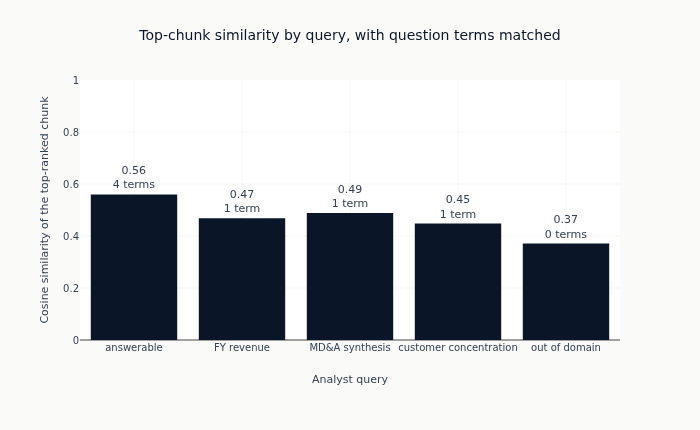

In [23]:
QUERY_LABELS = [
    "answerable",
    "FY revenue",
    "MD&A synthesis",
    "customer concentration",
    "out of domain",
]
labels = QUERY_LABELS[: len(retrieval_checks)] + [
    f"query {check['query']}" for check in retrieval_checks[len(QUERY_LABELS) :]
]
top_scores = [check["top_similarity"] or 0.0 for check in retrieval_checks]
term_counts = [len(check["matched_terms"]) for check in retrieval_checks]

fig = go.Figure(
    go.Bar(
        x=labels,
        y=top_scores,
        marker_color=COLORS["blue"],
        text=[
            f"{score:.2f}<br>{count} term{'' if count == 1 else 's'}"
            for score, count in zip(top_scores, term_counts, strict=True)
        ],
        textposition="outside",
    )
)
fig.update_layout(
    title="Top-chunk similarity by query, with question terms matched",
    xaxis_title="Analyst query",
    yaxis_title="Cosine similarity of the top-ranked chunk",
    height=430,
    showlegend=False,
    margin=dict(t=80, b=90),
)
fig.update_yaxes(range=[0, 1])
show_plotly_with_alt(
    fig,
    "Five bars on a cosine-similarity axis running from zero to one. All five stand in the "
    "lower half of it, between roughly a third and a little over half the height of the "
    "axis. The answerable query is the tallest and carries four matched terms; the three "
    "financial queries follow at similar heights with one matched term each; the "
    "out-of-domain query is the shortest and matched none. The gap between the tallest and "
    "the shortest bar is smaller than the empty space above all of them.",
)

The bars occupy the lower half of the axis and differ from each other by less
than they differ from either end of it. That compression is the reason a raw
score cannot be a guardrail: the ordering is right, and the distance between
"this corpus answers your question" and "this corpus is about something else
entirely" is a fraction of the scale the number is reported on.

## 7. Numeric Workflow: Retrieve → Extract → Compute → Narrate

Numeric questions are where RAG most often fails silently: a fluent model
will happily *state* a computed figure it never actually calculated. The
safeguard is to keep arithmetic out of the language model entirely -
retrieve the evidence, **extract** the reported figures into a typed schema,
**compute** in Python, and **narrate** the result with a citation trace back
to the source chunks. The block below runs deterministically (no LLM), so the
extracted numbers and the computed aggregate are reproducible and auditable.

### Typed schema and figure extractor

`ExtractedFigure` is the typed schema each retrieved dollar amount is parsed
into; the regex normalizes `$X billion/million/thousand` into a USD float so
the computation step never re-parses free text.

In [24]:
@dataclass
class ExtractedFigure:
    raw: str
    value_usd: float
    source: str


_MONEY_RE = re.compile(r"\$\s?([\d,]+(?:\.\d+)?)\s?(billion|million|thousand)?", re.IGNORECASE)
_SCALE = {"billion": 1e9, "million": 1e6, "thousand": 1e3, "": 1.0}

### Extraction step

Walk `(text, source)` pairs - retrieved chunks or financial-statement
excerpts alike - pull every `$`-denominated figure into the typed schema, and
carry the source id so each value remains citable.

In [25]:
def extract_dollar_figures(items) -> list[ExtractedFigure]:
    """Pull $-denominated figures from (text, source) pairs into a typed schema."""
    figures: list[ExtractedFigure] = []
    for text, source in items:
        for match in _MONEY_RE.finditer(text):
            amount = float(match.group(1).replace(",", ""))
            scale = _SCALE[(match.group(2) or "").lower()]
            figures.append(
                ExtractedFigure(raw=match.group(0), value_usd=amount * scale, source=source)
            )
    return figures

### What the narrative corpus contains

The corpus loaded above stores narrative text - business description and
risk factors, cut around each filing's mention of suppliers - and carries
almost no dollar figures. The financial-statement tables live in a separate
exhibit a production system would ingest for numeric questions.

This is the same failure section 6 measured, in a form that can be checked
without judgment. Retrieve a numeric question against this index and it
returns its `top_k` chunks as always; count the `$`-denominated figures in
them and there are none. The retriever reported nothing wrong either time.
What differs is that a figure count is falsifiable and a hit count is not.

In [26]:
NUMERIC_QUESTION = (
    "What are the largest reported dollar figures in the filing's financial discussion?"
)

numeric_retriever = index.as_retriever(similarity_top_k=TOP_K) if index is not None else None
if numeric_retriever is not None:
    narrative_nodes = numeric_retriever.retrieve(NUMERIC_QUESTION)
    narrative_figures = extract_dollar_figures(
        (n.text, n.metadata.get("accession_no", n.metadata.get("symbol", "?")))
        for n in narrative_nodes
    )
    print(f"Question: {NUMERIC_QUESTION}")
    print(
        f"Retrieved {len(narrative_nodes)} narrative chunks; "
        f"extracted {len(narrative_figures)} dollar figures."
    )
    if not narrative_figures:
        print("Narrative sections carry no financial figures -> route numeric questions")
        print("to the financial-statement exhibit (illustrated below).")
    else:
        print(
            f"Found {len(narrative_figures)} figure(s) in narrative chunks; the "
            "financial-statement exhibit (below) remains the authoritative source."
        )
else:
    print("No index available - cannot run numeric workflow.")

Question: What are the largest reported dollar figures in the filing's financial discussion?
Retrieved 5 narrative chunks; extracted 0 dollar figures.
Narrative sections carry no financial figures -> route numeric questions
to the financial-statement exhibit (illustrated below).


### Retrieve → Extract → Compute → Narrate on financial-statement evidence

The controlled excerpts below stand in for the financial-statement section of a 10-K
(the part the narrative corpus omits). They carry the real reported figures
an analyst would query. The mechanism is the lesson: each retrieved excerpt
is parsed into the typed `ExtractedFigure` schema, the year-over-year change
is computed **in Python**, and the result is narrated with a citation to the
source excerpt. They test arithmetic provenance, not retrieval accuracy.

In [27]:
# Controlled financial-statement fixtures for the arithmetic oracle.
FINANCIAL_EXCERPTS = [
    {"id": "fs_total_2023", "text": "Total net sales were $383.3 billion in fiscal 2023."},
    {"id": "fs_total_2022", "text": "Total net sales were $394.3 billion in fiscal 2022."},
    {"id": "fs_products_2023", "text": "Products net sales were $298.1 billion in fiscal 2023."},
    {"id": "fs_services_2023", "text": "Services net sales were $85.2 billion in fiscal 2023."},
]


figures = {
    f.source: f for f in extract_dollar_figures((e["text"], e["id"]) for e in FINANCIAL_EXCERPTS)
}

# Compute year-over-year total-net-sales growth in code.
total_2023 = figures["fs_total_2023"].value_usd
total_2022 = figures["fs_total_2022"].value_usd
yoy_growth = (total_2023 - total_2022) / total_2022

# Consistency check: products + services should reconcile to total net sales.
products_2023 = figures["fs_products_2023"].value_usd
services_2023 = figures["fs_services_2023"].value_usd
segment_sum = products_2023 + services_2023

print("Extract -> Compute trace (arithmetic done in Python, not by an LLM):")
for fid, fig in figures.items():
    print(f"  {fig.raw:>18}  = ${fig.value_usd:,.0f}   [source: {fid}]")
print(f"\n  YoY total net sales growth: {yoy_growth:.1%} (sources fs_total_2023, fs_total_2022)")
print(
    f"  Products + Services FY2023: ${segment_sum:,.0f} "
    f"vs reported total ${total_2023:,.0f} "
    f"(reconciles: {abs(segment_sum - total_2023) < 1e8})"
)
assert abs(segment_sum - total_2023) < 1e8
assert abs(yoy_growth - ((383.3 - 394.3) / 394.3)) < 1e-12

Extract -> Compute trace (arithmetic done in Python, not by an LLM):
      $383.3 billion  = $383,300,000,000   [source: fs_total_2023]
      $394.3 billion  = $394,300,000,000   [source: fs_total_2022]
      $298.1 billion  = $298,100,000,000   [source: fs_products_2023]
       $85.2 billion  = $85,200,000,000   [source: fs_services_2023]

  YoY total net sales growth: -2.8% (sources fs_total_2023, fs_total_2022)
  Products + Services FY2023: $383,300,000,000 vs reported total $383,300,000,000 (reconciles: True)


The language model is kept out of exactly one step: the arithmetic. It may
retrieve, it may extract into the typed schema, and it may narrate the
result, but the subtraction and the division happen in Python on values that
each carry a source id. A model asked to compute a growth rate will produce a
plausible number whether or not it computed anything, and no amount of
prompting makes that checkable. Moving the arithmetic out makes it checkable
by construction - the reconciliation assertion above either holds or stops
the notebook.

## 8. Summary

| Component | Implementation |
|-----------|---------------|
| **Document Loading** | Canonical parquet records; sorted flat-file fallback |
| **Document Parsing** | SentenceSplitter sentence windows |
| **Chunking** | SentenceSplitter (512 tokens, 50 overlap) |
| **Embeddings** | BGE-small-en (local); voyage-finance-2 or text-embedding-3 for production |
| **Vector Store** | ChromaDB (isolated rebuild for each run) |
| **Retrieval** | Top-k similarity search |
| **Generation** | Retrieval-only default; GPT-4o-mini only when `RUN_LIVE_LLM=True` |
| **Evaluation** | Lightweight harness diagnostics |

The Evaluation row is the weakest in the table and the summary below shows
why: coverage cannot fail, and the citation and abstention rates have no
generated answer to score. What the run does establish is the retrieval half,
and section 6 establishes it is not working on two of three questions.

In [28]:
print("=== 10-K RAG Assistant Summary ===\n")

print(f"Documents processed: {len(documents) if documents else 0}")
print(f"Queries executed: {len(query_results)}")
print(f"Successful queries: {sum(1 for r in query_results if r['status'] == 'success')}")
print(f"Retrieval top_k: {TOP_K}")

if ragas_metrics:
    print("\nHarness Metrics:")
    for metric, value in ragas_metrics.items():
        if value is None:
            print(f"  {metric}: n/a (LLM disabled)")
        elif isinstance(value, float):
            print(f"  {metric}: {value:.2%}")
        else:
            print(f"  {metric}: {value}")

=== 10-K RAG Assistant Summary ===

Documents processed: 20
Queries executed: 5
Successful queries: 5
Retrieval top_k: 5

Harness Metrics:
  retrieval_coverage: 100.00%
  citation_presence_rate: n/a (LLM disabled)
  abstention_rate: n/a (LLM disabled)
  n_queries: 5
  mode: retrieval_only


## Key takeaways

1. **A hit count is not a retrieval metric.** `similarity_top_k` has no
   relevance threshold, so it returns k chunks for every query an index can
   be asked, including ones about companies and years the corpus does not
   hold. Retrieval coverage therefore comes out whole in this run, including
   for a question about the boiling point of helium. Any check
   whose failing case is "the index did not build" is checking ingestion.

2. **A similarity score ranks; it does not decide.** The five top scores
   order the questions correctly, answerable highest and out-of-domain
   lowest, so the embedding is doing its job. But they fall in a narrow band
   with no zero in it, and the score for a question about helium is lower
   than the others rather than absent. Turning that ordering into an
   accept-or-abstain decision needs a threshold, and the threshold is a
   property of the corpus and the model that has to be calibrated against
   questions whose answers are known. The calibration is the work; the score
   on its own is not a guardrail.

3. **The corpus decides which questions are askable.** These are narrative
   excerpts cut around supplier discussion. Questions about fiscal-year
   revenue growth and customer concentration have no evidence here, and the
   numeric section confirms it by a route that cannot be argued with: zero
   dollar figures in the retrieved chunks.

4. **Keep the arithmetic out of the model.** Retrieve, extract into a typed
   schema, compute in Python, narrate with the source ids. A model asked to
   compute produces a plausible number either way, and the difference is not
   visible in the answer.

5. **The citation and abstention contract is stated here and not exercised.**
   `RUN_LIVE_LLM` is off, so `CITATION_PROMPT` is never sent and both rates
   report as unavailable rather than as passing.
   [`04_ragas_evaluation`](04_ragas_evaluation.ipynb) is where those checkers
   are run against fixtures that make them fire.

**Next**: [`06_esg_rag_vs_finetune`](06_esg_rag_vs_finetune.ipynb) compares
retrieval against a fine-tuned classifier on ESG analysis.